# Contest Insights Analysis

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## Load Data

In [21]:
codeforces = pd.read_csv('../data/codeforces.csv')
atcoder = pd.read_csv('../data/atcoder.csv')
codechef = pd.read_csv('../data/codechef.csv')
leetcode = pd.read_csv('../data/leetcode.csv')

print(f"Codeforces: {len(codeforces)} contests")
print(f"AtCoder: {len(atcoder)} contests")
print(f"CodeChef: {len(codechef)} contests")
print(f"LeetCode: {len(leetcode)} contests")

Codeforces: 100 contests
AtCoder: 9 contests
CodeChef: 5 contests
LeetCode: 693 contests


## Standardize and Combine

In [22]:
def standardize_df(df, date_col, name_col, duration_col=None):
    result = pd.DataFrame()
    result['platform'] = df['platform']
    result['contest_name'] = df[name_col]
    dt = pd.to_datetime(df[date_col], format='mixed', dayfirst=False)
    result['start_date'] = dt.dt.tz_localize(None) if dt.dt.tz is not None else dt
    
    if duration_col and duration_col in df.columns:
        result['duration_min'] = df[duration_col]
    else:
        result['duration_min'] = np.nan
    return result

codeforces_std = standardize_df(codeforces, 'date', 'name', 'duration_mins')
atcoder_std = standardize_df(atcoder, 'date', 'name')
codechef_std = standardize_df(codechef, 'date', 'name', 'duration_mins')
leetcode_std = standardize_df(leetcode, 'start_date', 'contest_name', 'duration_min')

all_contests = pd.concat([codeforces_std, atcoder_std, codechef_std, leetcode_std], ignore_index=True)
all_contests = all_contests.sort_values('start_date', ascending=False).reset_index(drop=True)

print(f"Total: {len(all_contests)} contests")
print(all_contests.head())

Total: 807 contests
   platform                                       contest_name  \
0   AtCoder  Ⓐ◉第七回日本最強プログラマー学生選手権～Advance～ -予選- （AtCoder Be...   
1   AtCoder                     Ⓐ◉AtCoder Beginner Contest 463   
2  CodeChef                                       Starters 243   
3   AtCoder                      Ⓐ◉AtCoder Regular Contest 222   
4   AtCoder  Ⓐ◉CodeQUEEN 2026 -qual- (AtCoder Beginner Cont...   

           start_date  duration_min  
0 2026-06-27 21:00:00           NaN  
1 2026-06-20 21:00:00           NaN  
2 2026-06-17 20:00:00         120.0  
3 2026-06-14 21:00:00           NaN  
4 2026-06-13 21:00:00           NaN  


## Upcoming Contests

In [23]:
now = datetime.now()
upcoming = all_contests[all_contests['start_date'] > now].copy()
upcoming = upcoming.sort_values('start_date')

print(f"Upcoming: {len(upcoming)} contests\n")
print(upcoming[['platform', 'contest_name', 'start_date', 'duration_min']].to_string())
print(f"\nBy platform:")
print(upcoming['platform'].value_counts())

Upcoming: 18 contests

      platform                                                                                      contest_name          start_date  duration_min
17    CodeChef                                                         Weekend Dev Challenge 51: Golang Projects 2026-05-23 00:00:00        2880.0
16    LeetCode                                                                              Biweekly Contest 183 2026-05-23 20:00:00          90.0
15  Codeforces                               Spectral::Cup 2026 Round 2 (Codeforces Round 1100, Div. 1 + Div. 2) 2026-05-23 20:05:00         180.0
14     AtCoder  Ⓐ◉Tokio Marine & Nichido Fire Insurance Programming Contest 2026  (AtCoder Beginner Contest 459) 2026-05-23 21:00:00           NaN
13    LeetCode                                                                                Weekly Contest 503 2026-05-24 08:00:00          90.0
12    CodeChef                                                                                 

## LeetCode Contest Types

contest_type
Weekly      504
Biweekly    183
Other         6
Name: count, dtype: int64


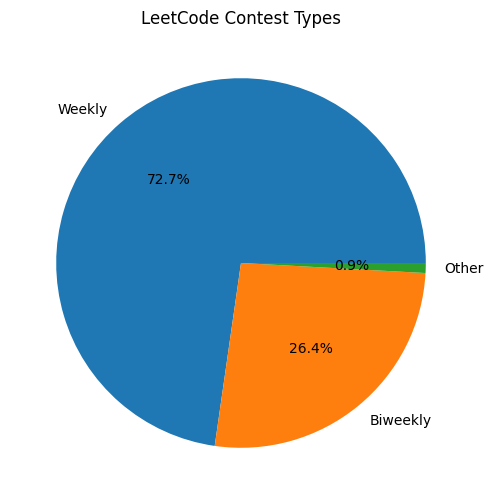

In [24]:
leetcode['contest_type'] = leetcode['contest_name'].apply(
    lambda x: 'Biweekly' if 'Biweekly' in x else 'Weekly' if 'Weekly' in x else 'Other'
)

print(leetcode['contest_type'].value_counts())

plt.figure(figsize=(8, 6))
leetcode['contest_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('LeetCode Contest Types')
plt.ylabel('')
plt.show()

## Contests Per Platform

platform
LeetCode      693
Codeforces    100
AtCoder         9
CodeChef        5
Name: count, dtype: int64


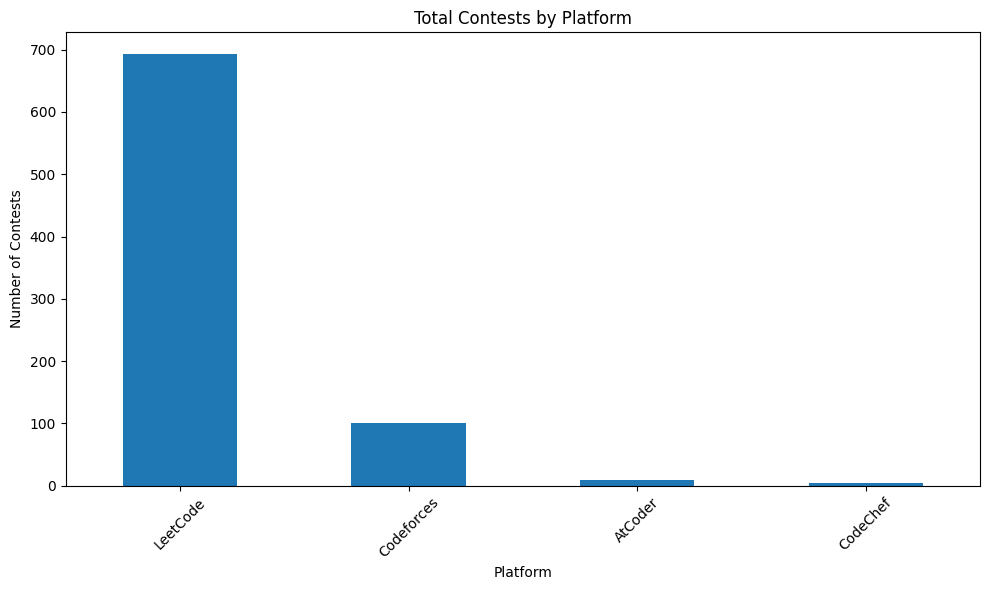

In [25]:
platform_counts = all_contests['platform'].value_counts().sort_values(ascending=False)
print(platform_counts)

plt.figure(figsize=(10, 6))
platform_counts.plot(kind='bar')
plt.title('Total Contests by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Contests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Duration by Platform

              avg    min      max
platform                         
AtCoder       NaN    NaN      NaN
CodeChef    672.0  120.0   2880.0
Codeforces  648.2   60.0  23040.0
LeetCode     94.6   90.0   1440.0


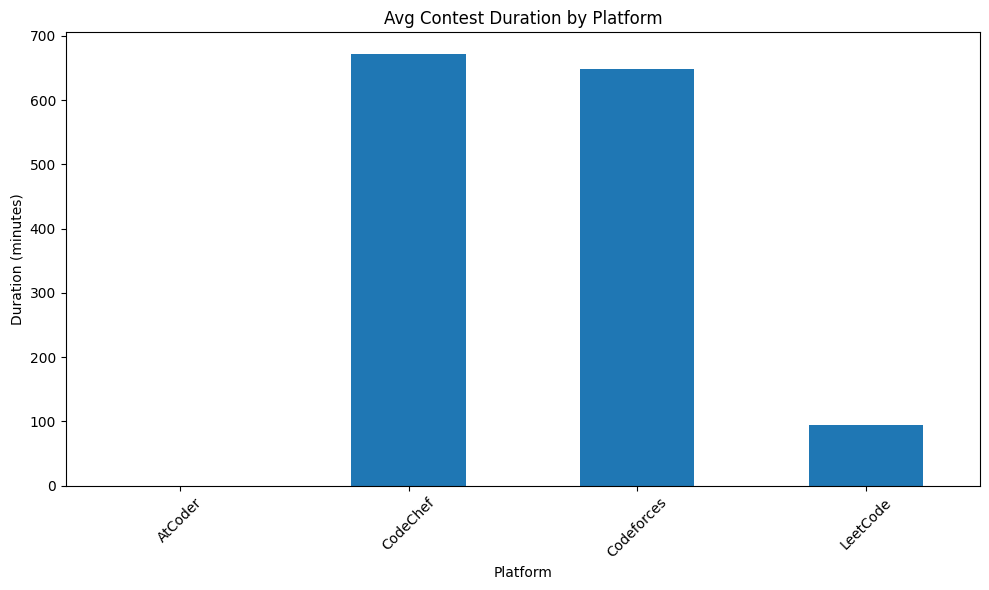

In [26]:
duration_stats = all_contests.groupby('platform')['duration_min'].agg([
    ('avg', 'mean'),
    ('min', 'min'),
    ('max', 'max')
]).round(1)

print(duration_stats)

plt.figure(figsize=(10, 6))
duration_stats['avg'].plot(kind='bar')
plt.title('Avg Contest Duration by Platform')
plt.xlabel('Platform')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly Activity

    year_month  count year_month_str
0      2016-08      2        2016-08
1      2016-09      4        2016-09
2      2016-10      5        2016-10
3      2016-11      3        2016-11
4      2016-12      3        2016-12
..         ...    ...            ...
114    2026-02     17        2026-02
115    2026-03     15        2026-03
116    2026-04     17        2026-04
117    2026-05     19        2026-05
118    2026-06      8        2026-06

[119 rows x 3 columns]


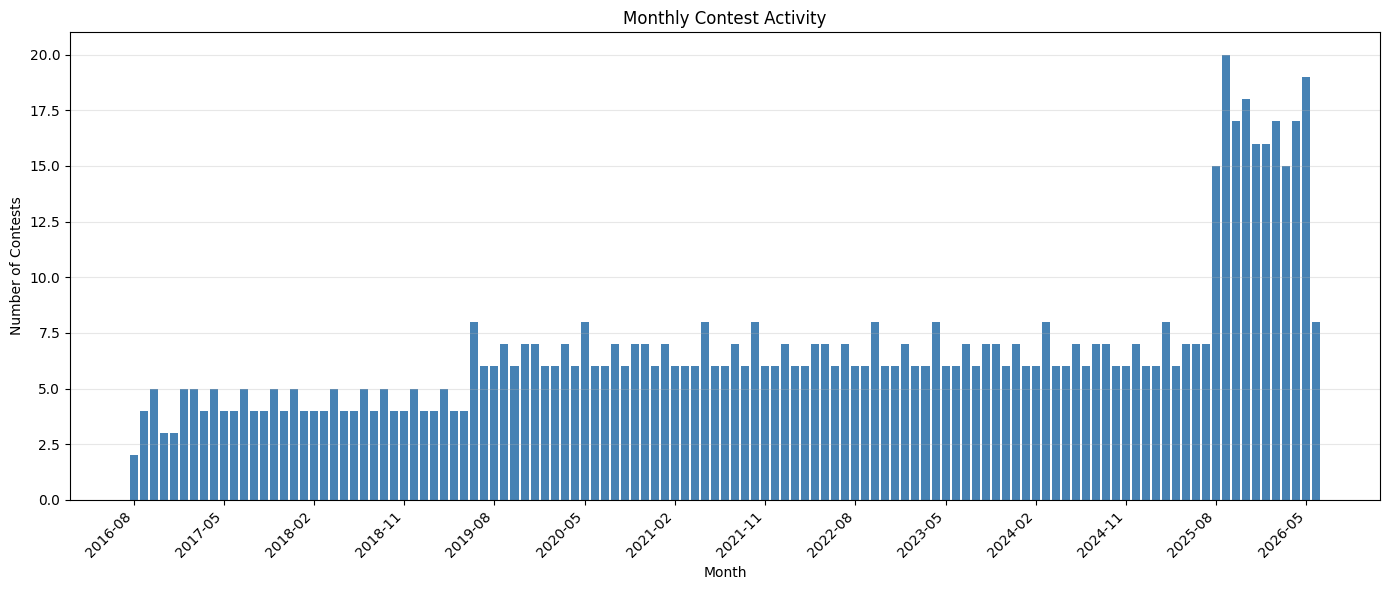

In [33]:
all_contests['year_month'] = all_contests['start_date'].dt.to_period('M')
monthly = all_contests.groupby('year_month').size().reset_index(name='count')
monthly['year_month_str'] = monthly['year_month'].astype(str)

print(monthly)

plt.figure(figsize=(14, 6))
plt.bar(range(len(monthly)), monthly['count'], color='steelblue')
plt.xlabel('Month')
plt.ylabel('Number of Contests')
plt.title('Monthly Contest Activity')

# Show every 12th label
step = max(1, len(monthly) // 12)
tick_positions = range(0, len(monthly), step)
tick_labels = [monthly['year_month_str'].iloc[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Day of Week Distribution

day_of_week
Monday        15
Tuesday        8
Wednesday     16
Thursday      15
Friday        13
Saturday     210
Sunday       530
Name: count, dtype: int64


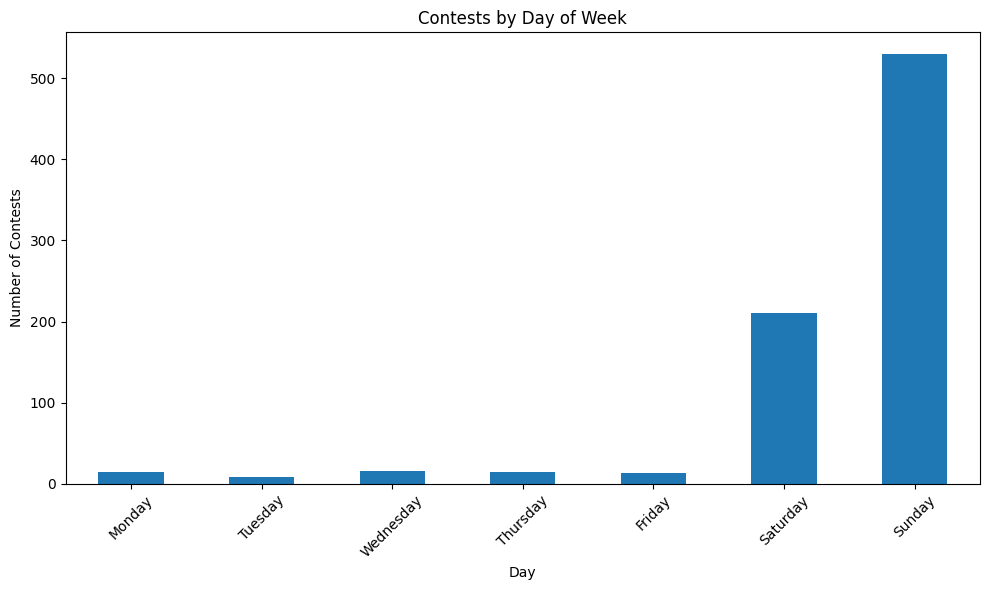

In [28]:
all_contests['day_of_week'] = all_contests['start_date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = all_contests['day_of_week'].value_counts().reindex(day_order)

print(day_counts)

plt.figure(figsize=(10, 6))
day_counts.plot(kind='bar')
plt.title('Contests by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Contests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Combined Data

In [29]:
all_contests_clean = all_contests[['platform', 'contest_name', 'start_date', 'duration_min', 'day_of_week']]
all_contests_clean.to_csv('../data/all_contests.csv', index=False)
print(f"Saved: all_contests.csv ({len(all_contests_clean)} contests)")

Saved: all_contests.csv (807 contests)


## Summary

In [30]:
print(f"Total contests: {len(all_contests)}")
print(f"Upcoming: {len(upcoming)}")
print(f"Past: {len(all_contests) - len(upcoming)}")
print(f"Date range: {all_contests['start_date'].min().date()} to {all_contests['start_date'].max().date()}")
print(f"Avg duration: {all_contests['duration_min'].mean():.1f} minutes")

Total contests: 807
Upcoming: 18
Past: 789
Date range: 2016-08-21 to 2026-06-27
Avg duration: 167.6 minutes
